# Experiment 4: Data Wrangling and Data Visualization

Shaun Michael R. Remular

2ECE-C

In [188]:
import pandas as pd

In [189]:
ECE = pd.read_excel('board2.xlsx')
ECE
#There is no column for Average

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [190]:
ECE['Average'] = ECE.mean(axis=1, numeric_only = True)
ECE

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


## A. Visayas Communication Dataframe

In [191]:
VisComm = pd.DataFrame(ECE, columns = ['Name', 'Gender', 'Math', 'Electronics', 'Average']).loc[(ECE['Hometown']=='Visayas')&(ECE['Track']=='Communication')]
VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


## B. Visayas Female Dataframe

In [192]:
VisFemale = pd.DataFrame(ECE, columns = ['Name', 'Track', 'GEAS','Electronics', 'Average']).loc[(ECE['Gender']=='Female')]
VisFemale

,Name,Track,GEAS,Electronics,Average
1,S2,Communication,90,75,67.25
2,S3,Instrumentation,77,74,72.75
5,S6,Microelectronics,86,45,75.50
6,S7,Instrumentation,60,60,58.50
10,S11,Communication,48,56,54.75
12,S13,Microelectronics,83,35,62.25
13,S14,Microelectronics,89,77,80.50
14,S15,Microelectronics,40,41,59.00
15,S16,Communication,87,70,77.25
16,S17,Microelectronics,77,79,70.50


In [193]:
VisFemale.loc[(VisFemale['Average']>60)]

,Name,Track,GEAS,Electronics,Average
1,S2,Communication,90,75,67.25
2,S3,Instrumentation,77,74,72.75
5,S6,Microelectronics,86,45,75.50
12,S13,Microelectronics,83,35,62.25
13,S14,Microelectronics,89,77,80.50
15,S16,Communication,87,70,77.25
16,S17,Microelectronics,77,79,70.50
19,S20,Communication,62,60,66.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50


## C. Category-Average Visualization

In [194]:
import matplotlib.pyplot as plt

In [195]:
meanTrack = ECE.groupby('Track')['Average'].mean()
meanGender = ECE.groupby('Gender')['Average'].mean()
meanHometown = ECE.groupby('Hometown')['Average'].mean()

In [196]:
meanTrack

,Average
Track,
Communication,67.975
Instrumentation,65.225
Microelectronics,67.500


In [197]:
meanGender

,Average
Gender,
Female,66.616667
Male,67.183333


In [198]:
meanHometown

,Average
Hometown,
Luzon,68.083333
Mindanao,66.678571
Visayas,65.750000


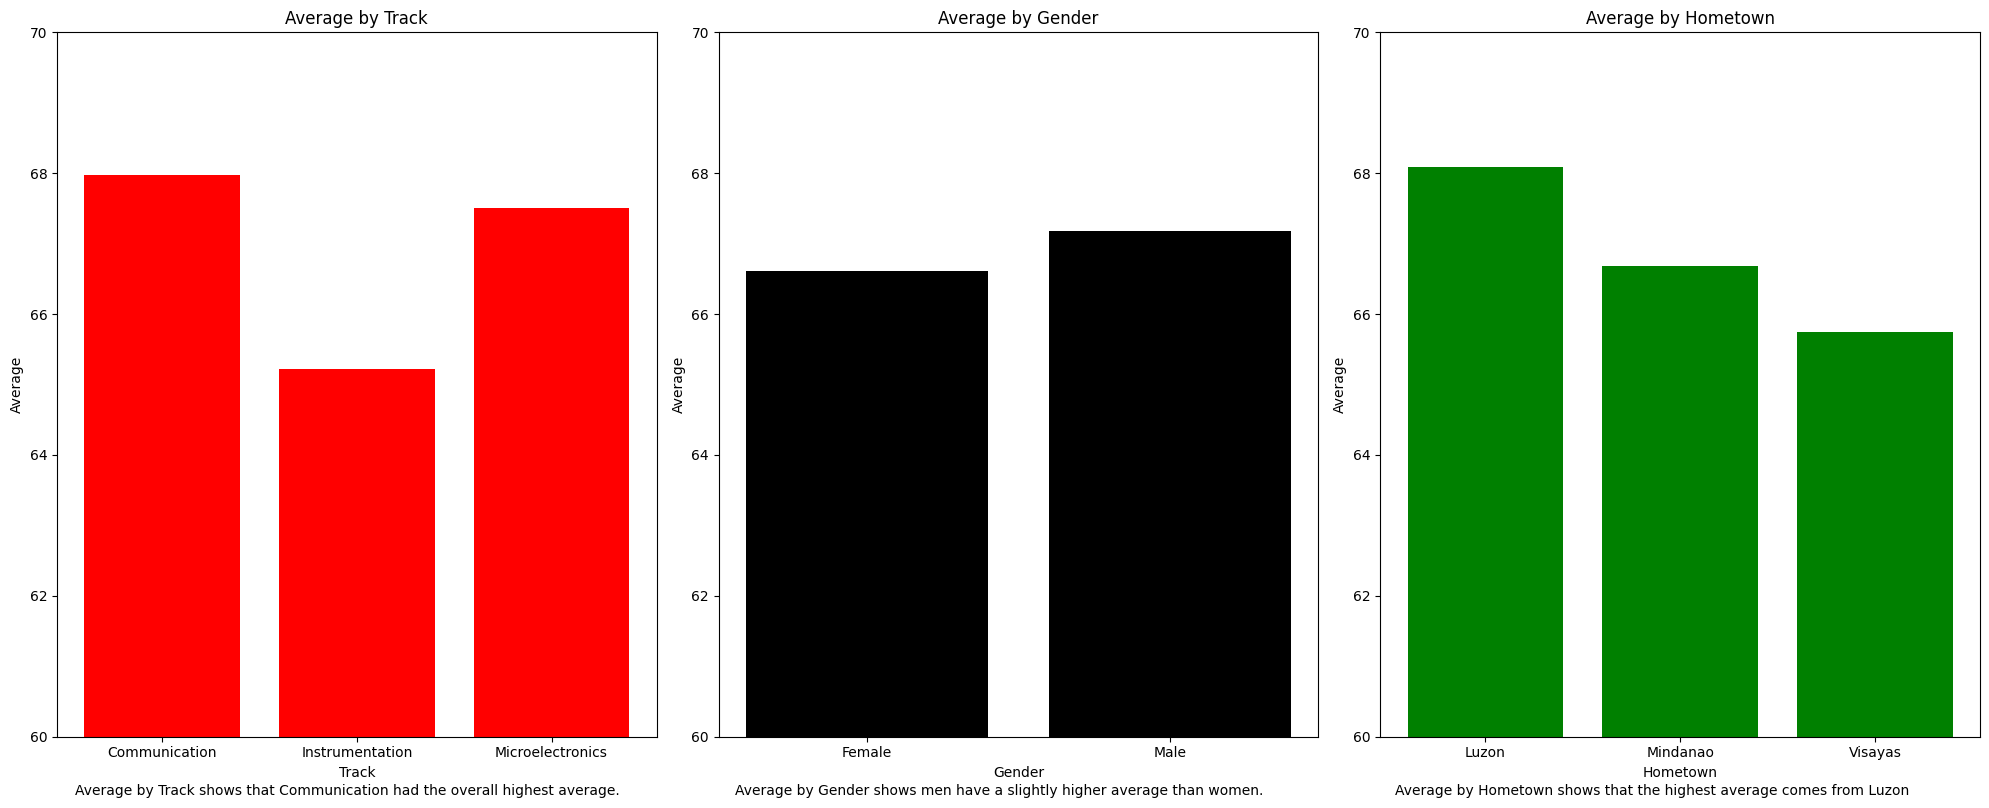

In [199]:
fig, ax = plt.subplots(1, 3, figsize=(20,8))

ax[0].bar(meanTrack.index, meanTrack.values, color = 'Red')
ax[0].set(ylim=[60, 70])
ax[0].set(title='Average by Track', ylabel='Average', xlabel='Track')

ax[1].bar(meanGender.index, meanGender.values, color='Black')
ax[1].set(ylim=[60, 70])
ax[1].set(title='Average by Gender', ylabel='Average', xlabel='Gender')

ax[2].bar(meanHometown.index, meanHometown.values, color='Green')
ax[2].set(ylim=[60, 70])
ax[2].set(title='Average by Hometown', ylabel='Average', xlabel='Hometown')

fig.text(0.7,0,'Average by Hometown shows that the highest average comes from Luzon')
fig.text(0.04,0,'Average by Track shows that Communication had the overall highest average.')
fig.text(0.37,0,'Average by Gender shows men have a slightly higher average than women.')

plt.tight_layout()
plt.show()